# ROI-Based Segmentation Evaluation

This notebook evaluates segmentation metrics **within a Region of Interest (ROI)** derived from the ground truth annotations.

The ROI is created using morphological closing on the ground truth stone masks, which:
- Bridges gaps/joints between stones (keeping them in the evaluation)
- Excludes areas outside the annotated facade (removing out-of-bond detections from metrics)

## Workflow:
1. **Set parameters** (paths, kernel size)
2. **Generate & visualize ROI** - adjust kernel size if needed
3. **Run evaluation** within the ROI

---
## Cell 1: Parameters

Set your paths and kernel size here. Re-run subsequent cells after changing these.

In [117]:
# ============================================================
# PARAMETERS - EDIT THESE
# ============================================================

# Paths to your masks
GT_MASK_PATH = r"C:\Users\admin\Desktop\OrdnerAmGArtikel2025\AWS_TRAINING\2025-08-10_4classEX\testing\02_masks\Kaunos_Isodom_png-ortho.png"  # Ground truth RGB mask
PRED_MASK_PATH = r"C:\Users\admin\Desktop\OrdnerAmGArtikel2025\AWS_TRAINING\2025-08-10_4classEX\testing\05_outputs\7-channel\Kaunos_Isodom_png-ortho_RAW_combined.png"
   # Predicted RGB mask

# Output directory for results
OUTPUT_DIR = "C:/Users/admin/Desktop/OrdnerAmGArtikel2025/AWS_TRAINING/2025-08-10_4classEX/testing/07_ROI_evaluation/Wall4"

# ROI Generation Parameters
# ---------------------------
# Kernel size for morphological closing (in pixels)
# This should be large enough to bridge gaps between stones.
# With gaps of 5-10cm and resolution of ~2-6 mm/px, gaps are roughly 8-60 pixels.
# A kernel of 60-80 pixels should work well. Adjust based on visualization.
KERNEL_RADIUS = 100  # Radius of the disk structuring element (diameter = 2*radius + 1)

# Class names (should match your color scheme)
CLASS_NAMES = ['Background', 'Ashlar', 'Polygonal', 'Quarry Stone']

print(f"Ground Truth: {GT_MASK_PATH}")
print(f"Prediction:   {PRED_MASK_PATH}")
print(f"Output Dir:   {OUTPUT_DIR}")
print(f"Kernel Radius: {KERNEL_RADIUS} pixels (diameter: {2*KERNEL_RADIUS + 1})")

Ground Truth: C:\Users\admin\Desktop\OrdnerAmGArtikel2025\AWS_TRAINING\2025-08-10_4classEX\testing\02_masks\Kaunos_Isodom_png-ortho.png
Prediction:   C:\Users\admin\Desktop\OrdnerAmGArtikel2025\AWS_TRAINING\2025-08-10_4classEX\testing\05_outputs\7-channel\Kaunos_Isodom_png-ortho_RAW_combined.png
Output Dir:   C:/Users/admin/Desktop/OrdnerAmGArtikel2025/AWS_TRAINING/2025-08-10_4classEX/testing/07_ROI_evaluation/Wall4
Kernel Radius: 100 pixels (diameter: 201)


---
## Cell 2: Imports and Setup

In [118]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns
from PIL import Image
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report
from scipy import ndimage
from skimage.morphology import disk, binary_closing
from typing import Dict, Tuple, List
import os
import warnings
warnings.filterwarnings('ignore')

Image.MAX_IMAGE_PIXELS = None

# RGB to class mapping
RGB_TO_CLASS = {
    (0, 0, 0): 0,       # Black -> Background
    (0, 0, 255): 1,     # Blue -> Ashlar
    (255, 0, 0): 2,     # Red -> Polygonal
    (255, 255, 0): 3    # Yellow -> Quarry Stone
}

CLASS_COLORS = ['#000000', '#0000FF', '#FF0000', '#FFFF00']

print("Imports complete.")

Imports complete.


---
## Cell 3: Helper Functions

In [119]:
def rgb_to_class_mask(rgb_image: np.ndarray) -> np.ndarray:
    """
    Convert RGB mask to class indices.
    Handles unmapped colors by assigning to nearest class.
    """
    height, width = rgb_image.shape[:2]
    class_mask = np.zeros((height, width), dtype=np.uint8)
    
    for rgb_tuple, class_idx in RGB_TO_CLASS.items():
        color_mask = np.all(rgb_image == rgb_tuple, axis=2)
        class_mask[color_mask] = class_idx
    
    # Handle unmapped pixels (compression artifacts, anti-aliasing)
    mapped_pixels = np.zeros((height, width), dtype=bool)
    for rgb_tuple in RGB_TO_CLASS.keys():
        mapped_pixels |= np.all(rgb_image == rgb_tuple, axis=2)
    
    unmapped_count = np.sum(~mapped_pixels)
    if unmapped_count > 0:
        print(f"  Note: {unmapped_count} pixels with unmapped colors -> mapped to nearest class")
        unmapped_indices = np.where(~mapped_pixels)
        for i in range(len(unmapped_indices[0])):
            y, x = unmapped_indices[0][i], unmapped_indices[1][i]
            pixel_rgb = rgb_image[y, x]
            min_dist = float('inf')
            nearest_class = 0
            for rgb_tuple, class_idx in RGB_TO_CLASS.items():
                dist = np.sqrt(np.sum((pixel_rgb.astype(float) - np.array(rgb_tuple).astype(float))**2))
                if dist < min_dist:
                    min_dist = dist
                    nearest_class = class_idx
            class_mask[y, x] = nearest_class
    
    return class_mask


def generate_roi_from_ground_truth(gt_class_mask: np.ndarray, kernel_radius: int) -> np.ndarray:
    """
    Generate ROI mask using morphological closing on stone classes.
    
    Args:
        gt_class_mask: Ground truth with class indices (0=bg, 1,2,3=stones)
        kernel_radius: Radius of disk structuring element
    
    Returns:
        Binary ROI mask (True = inside ROI, False = outside)
    """
    # Create binary mask: all stone classes -> 1, background -> 0
    stone_mask = (gt_class_mask > 0).astype(np.uint8)
    
    print(f"  Stone pixels before closing: {np.sum(stone_mask):,}")
    
    # Create disk structuring element
    selem = disk(kernel_radius)
    print(f"  Structuring element: disk with radius {kernel_radius} (diameter {2*kernel_radius + 1})")
    
    # Apply morphological closing (dilation followed by erosion)
    roi_mask = binary_closing(stone_mask, selem)
    
    print(f"  ROI pixels after closing: {np.sum(roi_mask):,}")
    print(f"  Pixels added by closing (gaps bridged): {np.sum(roi_mask) - np.sum(stone_mask):,}")
    
    return roi_mask.astype(bool)


def calculate_metrics_within_roi(
    gt_mask: np.ndarray, 
    pred_mask: np.ndarray, 
    roi_mask: np.ndarray,
    class_names: List[str]
) -> Tuple[Dict[str, float], Dict[str, Dict[str, float]]]:
    """
    Calculate IoU and F1 scores only within the ROI.
    
    Returns:
        Tuple of (iou_scores dict, f1_scores dict)
    """
    num_classes = len(class_names)
    
    # Flatten and filter to ROI only
    roi_flat = roi_mask.flatten()
    gt_flat = gt_mask.flatten()[roi_flat]
    pred_flat = pred_mask.flatten()[roi_flat]
    
    print(f"  Evaluating {len(gt_flat):,} pixels within ROI (out of {roi_mask.size:,} total)")
    
    # Calculate IoU per class
    iou_scores = {}
    for class_idx in range(num_classes):
        gt_binary = (gt_flat == class_idx)
        pred_binary = (pred_flat == class_idx)
        
        intersection = np.logical_and(gt_binary, pred_binary).sum()
        union = np.logical_or(gt_binary, pred_binary).sum()
        
        if union == 0:
            iou = 0.0 if intersection == 0 else 1.0
        else:
            iou = intersection / union
        
        iou_scores[class_names[class_idx]] = iou
    
    # Calculate F1 scores
    report = classification_report(
        gt_flat, pred_flat,
        labels=list(range(num_classes)),
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )
    
    f1_scores = {}
    for class_name in class_names:
        if class_name in report:
            f1_scores[class_name] = {
                'precision': report[class_name]['precision'],
                'recall': report[class_name]['recall'],
                'f1-score': report[class_name]['f1-score'],
                'support': report[class_name]['support']
            }
    f1_scores['macro_avg'] = report['macro avg']['f1-score']
    f1_scores['weighted_avg'] = report['weighted avg']['f1-score']
    
    return iou_scores, f1_scores


print("Helper functions defined.")

Helper functions defined.


---
## Cell 4: Load Masks and Generate ROI

This cell loads your masks and generates the ROI. **Visualize the result in the next cell** before proceeding.

In [120]:
# Load ground truth
print("Loading ground truth mask...")
gt_rgb = np.array(Image.open(GT_MASK_PATH).convert('RGB'))
gt_mask = rgb_to_class_mask(gt_rgb)
print(f"  Shape: {gt_mask.shape}")
print(f"  Classes present: {np.unique(gt_mask)}")

# Load prediction
print("\nLoading predicted mask...")
pred_rgb = np.array(Image.open(PRED_MASK_PATH).convert('RGB'))
pred_mask = rgb_to_class_mask(pred_rgb)
print(f"  Shape: {pred_mask.shape}")
print(f"  Classes present: {np.unique(pred_mask)}")

# Verify shapes match
assert gt_mask.shape == pred_mask.shape, f"Shape mismatch: GT {gt_mask.shape} vs Pred {pred_mask.shape}"

# Generate ROI
print(f"\nGenerating ROI with kernel radius = {KERNEL_RADIUS}...")
roi_mask = generate_roi_from_ground_truth(gt_mask, KERNEL_RADIUS)

print("\n✓ Masks loaded and ROI generated. Proceed to visualization.")

Loading ground truth mask...
  Shape: (7880, 11225)
  Classes present: [0 1 2 3]

Loading predicted mask...
  Shape: (7880, 11225)
  Classes present: [0 1 2 3]

Generating ROI with kernel radius = 100...
  Stone pixels before closing: 30,538,608
  Structuring element: disk with radius 100 (diameter 201)
  ROI pixels after closing: 31,776,242
  Pixels added by closing (gaps bridged): 1,237,634.0

✓ Masks loaded and ROI generated. Proceed to visualization.


---
## Cell 5: Visualize ROI

**Check this visualization carefully!**
- The ROI (green overlay) should cover all stones AND the gaps between them
- The ROI should NOT extend significantly beyond the facade boundaries

If the ROI is too small (gaps not bridged): **increase KERNEL_RADIUS** in Cell 1 and re-run from Cell 4.

If the ROI extends too far: **decrease KERNEL_RADIUS** in Cell 1 and re-run from Cell 4.

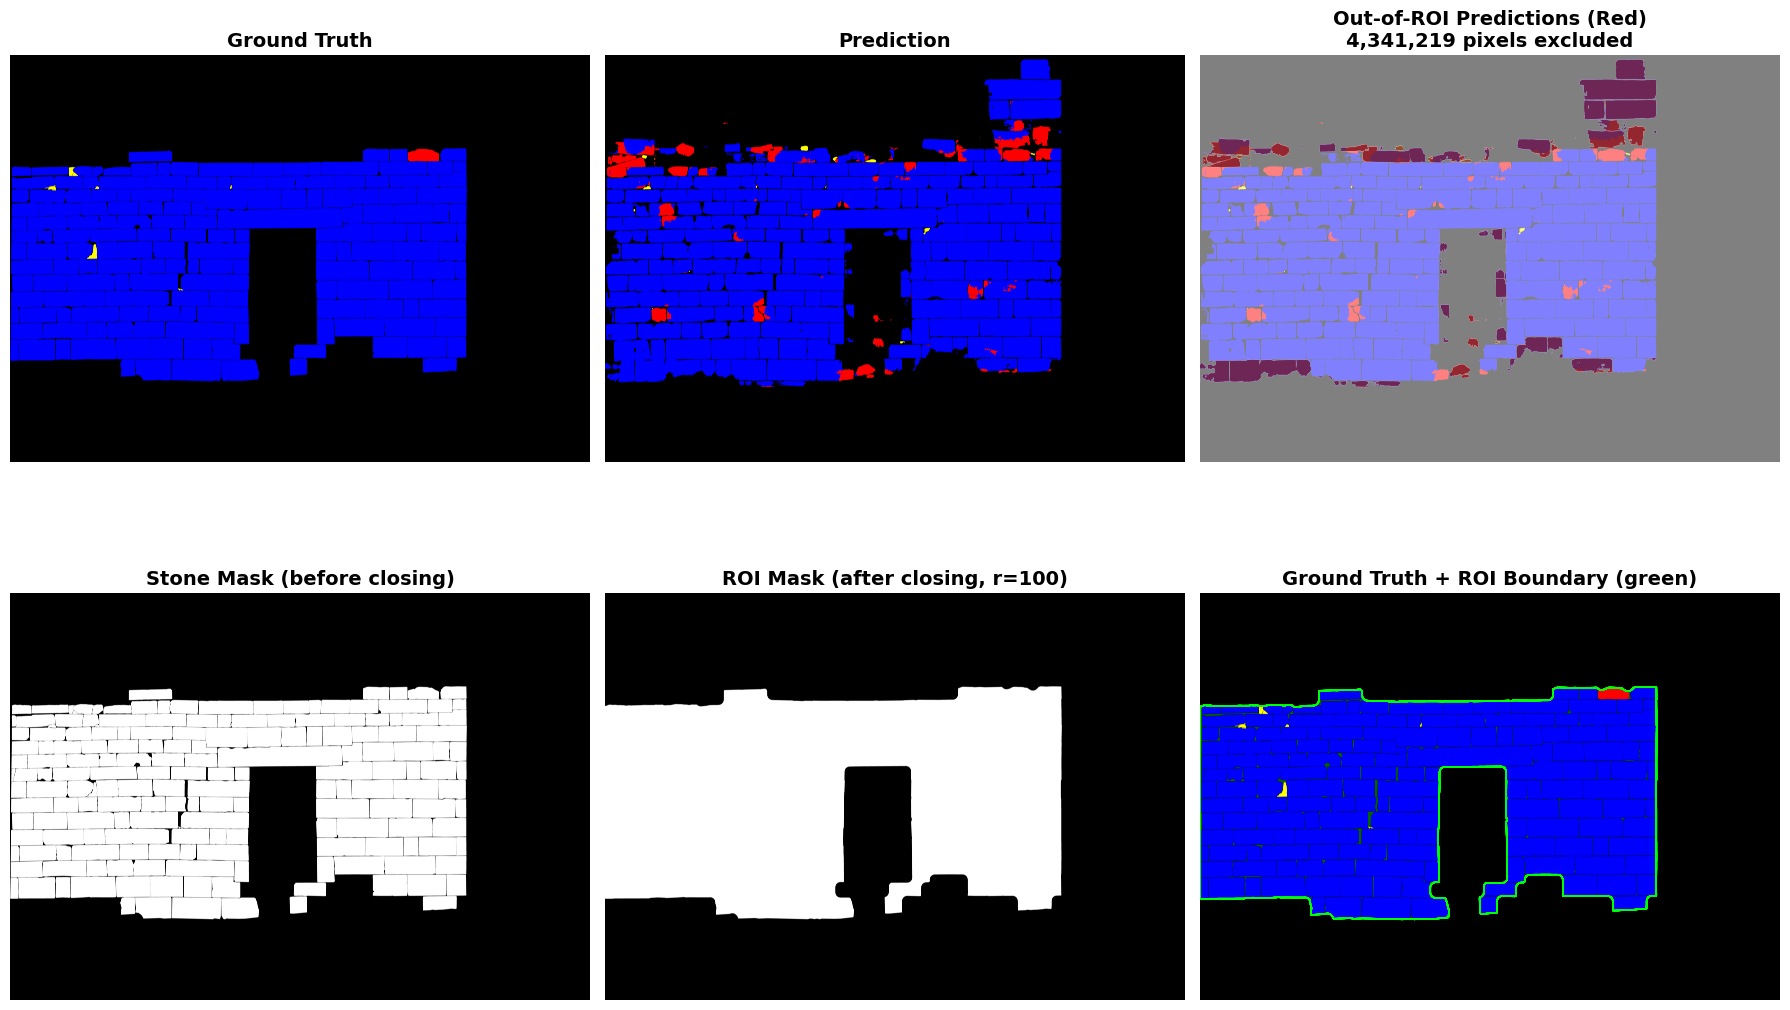


ROI STATISTICS
Total image pixels:        88,453,000
Stone pixels (GT):         30,538,608 (34.5%)
ROI pixels:                31,776,242 (35.9%)
Gap pixels (bridged):      1,237,634 (1.4%)

Out-of-ROI predictions:    4,341,219 pixels will be excluded from metrics

→ If ROI looks good, proceed to Cell 6 for evaluation.
→ If ROI needs adjustment, change KERNEL_RADIUS in Cell 1 and re-run from Cell 4.


In [121]:
# Visualization of ROI
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

cmap = ListedColormap(CLASS_COLORS)

# Row 1: Ground truth, Prediction, and Difference
axes[0, 0].imshow(gt_mask, cmap=cmap, vmin=0, vmax=3)
axes[0, 0].set_title('Ground Truth', fontsize=14, fontweight='bold')
axes[0, 0].axis('off')

axes[0, 1].imshow(pred_mask, cmap=cmap, vmin=0, vmax=3)
axes[0, 1].set_title('Prediction', fontsize=14, fontweight='bold')
axes[0, 1].axis('off')

# Show what will be excluded (out-of-ROI predictions)
out_of_roi_predictions = (pred_mask > 0) & ~roi_mask
axes[0, 2].imshow(pred_mask, cmap=cmap, vmin=0, vmax=3, alpha=0.5)
axes[0, 2].imshow(out_of_roi_predictions, cmap='Reds', alpha=0.7 * out_of_roi_predictions.astype(float))
axes[0, 2].set_title(f'Out-of-ROI Predictions (Red)\n{np.sum(out_of_roi_predictions):,} pixels excluded', 
                     fontsize=14, fontweight='bold')
axes[0, 2].axis('off')

# Row 2: ROI visualization
# Stone mask (before closing)
stone_mask = (gt_mask > 0)
axes[1, 0].imshow(stone_mask, cmap='gray')
axes[1, 0].set_title('Stone Mask (before closing)', fontsize=14, fontweight='bold')
axes[1, 0].axis('off')

# ROI mask (after closing)
axes[1, 1].imshow(roi_mask, cmap='gray')
axes[1, 1].set_title(f'ROI Mask (after closing, r={KERNEL_RADIUS})', fontsize=14, fontweight='bold')
axes[1, 1].axis('off')

# Overlay: GT with ROI boundary
# Create an overlay showing the ROI on top of the ground truth
overlay = np.zeros((*gt_mask.shape, 4))  # RGBA
# Add green tint where ROI extends beyond stones (the "bridged gaps")
bridged_gaps = roi_mask & (gt_mask == 0)
overlay[bridged_gaps] = [0, 1, 0, 0.4]  # Green with alpha

axes[1, 2].imshow(gt_mask, cmap=cmap, vmin=0, vmax=3)
axes[1, 2].imshow(overlay)
# Draw ROI contour
from scipy import ndimage
roi_boundary = roi_mask.astype(float) - ndimage.binary_erosion(roi_mask).astype(float)
axes[1, 2].contour(roi_boundary, colors='lime', linewidths=1)
axes[1, 2].set_title('Ground Truth + ROI Boundary (green)', fontsize=14, fontweight='bold')
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

# Print statistics
print("\n" + "="*60)
print("ROI STATISTICS")
print("="*60)
total_pixels = roi_mask.size
roi_pixels = np.sum(roi_mask)
stone_pixels = np.sum(gt_mask > 0)
gap_pixels = roi_pixels - stone_pixels
excluded_pred_pixels = np.sum(out_of_roi_predictions)

print(f"Total image pixels:        {total_pixels:,}")
print(f"Stone pixels (GT):         {stone_pixels:,} ({100*stone_pixels/total_pixels:.1f}%)")
print(f"ROI pixels:                {roi_pixels:,} ({100*roi_pixels/total_pixels:.1f}%)")
print(f"Gap pixels (bridged):      {gap_pixels:,} ({100*gap_pixels/total_pixels:.1f}%)")
print(f"\nOut-of-ROI predictions:    {excluded_pred_pixels:,} pixels will be excluded from metrics")
print("="*60)
print("\n→ If ROI looks good, proceed to Cell 6 for evaluation.")
print("→ If ROI needs adjustment, change KERNEL_RADIUS in Cell 1 and re-run from Cell 4.")

---
## Cell 6: Run Evaluation Within ROI

This cell calculates IoU and F1 metrics **only within the ROI**, excluding out-of-bond detections.

In [122]:
print("Calculating metrics within ROI...\n")

iou_scores, f1_scores = calculate_metrics_within_roi(gt_mask, pred_mask, roi_mask, CLASS_NAMES)

# Calculate mean IoU (excluding background)
stone_iou_values = [v for k, v in iou_scores.items() if k != 'Background']
mean_iou_stones = np.mean(stone_iou_values) if stone_iou_values else 0.0
mean_iou_all = np.mean(list(iou_scores.values()))

# Print results
print("\n" + "="*60)
print("EVALUATION RESULTS (Within ROI)")
print("="*60)

print("\nPer-Class IoU Scores:")
print("-"*40)
for class_name, iou in iou_scores.items():
    print(f"  {class_name:20s}: {iou:.4f}")

print(f"\n  Mean IoU (stone classes): {mean_iou_stones:.4f}")
print(f"  Mean IoU (all classes):   {mean_iou_all:.4f}")

print("\n\nPer-Class F1 Scores:")
print("-"*40)
for class_name in CLASS_NAMES:
    if class_name in f1_scores:
        m = f1_scores[class_name]
        print(f"\n  {class_name}:")
        print(f"    Precision: {m['precision']:.4f}")
        print(f"    Recall:    {m['recall']:.4f}")
        print(f"    F1-Score:  {m['f1-score']:.4f}")

print(f"\n  Macro F1-Score:    {f1_scores['macro_avg']:.4f}")
print(f"  Weighted F1-Score: {f1_scores['weighted_avg']:.4f}")
print("="*60)

Calculating metrics within ROI...

  Evaluating 31,776,242 pixels within ROI (out of 88,453,000 total)

EVALUATION RESULTS (Within ROI)

Per-Class IoU Scores:
----------------------------------------
  Background          : 0.3990
  Ashlar              : 0.9194
  Polygonal           : 0.1164
  Quarry Stone        : 0.1000

  Mean IoU (stone classes): 0.3786
  Mean IoU (all classes):   0.3837


Per-Class F1 Scores:
----------------------------------------

  Background:
    Precision: 0.4157
    Recall:    0.9085
    F1-Score:  0.5704

  Ashlar:
    Precision: 0.9953
    Recall:    0.9234
    F1-Score:  0.9580

  Polygonal:
    Precision: 0.1190
    Recall:    0.8430
    F1-Score:  0.2086

  Quarry Stone:
    Precision: 0.3735
    Recall:    0.1202
    F1-Score:  0.1819

  Macro F1-Score:    0.4797
  Weighted F1-Score: 0.9384


---
## Cell 7: Generate Report and Save Results

In [123]:
# Create output directory
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Build report dataframe
report_data = []
for class_name in CLASS_NAMES:
    row = {
        'Class': class_name,
        'IoU': iou_scores.get(class_name, 0.0),
        'Precision': f1_scores.get(class_name, {}).get('precision', 0.0),
        'Recall': f1_scores.get(class_name, {}).get('recall', 0.0),
        'F1-Score': f1_scores.get(class_name, {}).get('f1-score', 0.0),
        'Support': f1_scores.get(class_name, {}).get('support', 0)
    }
    report_data.append(row)

# Add summary rows
report_data.append({
    'Class': 'Mean (stone classes)',
    'IoU': mean_iou_stones,
    'Precision': '-',
    'Recall': '-',
    'F1-Score': f1_scores['macro_avg'],
    'Support': '-'
})

report_df = pd.DataFrame(report_data)

print("\nSummary Report:")
print(report_df.to_string(index=False))

# Save report
report_path = os.path.join(OUTPUT_DIR, 'roi_evaluation_report.csv')
report_df.to_csv(report_path, index=False)
print(f"\n✓ Report saved to: {report_path}")

# Save ROI mask for reference
roi_path = os.path.join(OUTPUT_DIR, 'roi_mask.png')
Image.fromarray((roi_mask * 255).astype(np.uint8)).save(roi_path)
print(f"✓ ROI mask saved to: {roi_path}")


Summary Report:
               Class      IoU Precision    Recall  F1-Score     Support
          Background 0.398961  0.415655   0.90854  0.570368   1237634.0
              Ashlar 0.919389  0.995279  0.923416  0.958002  30351119.0
           Polygonal 0.116420     0.119  0.843007  0.208559    125846.0
        Quarry Stone 0.100023  0.373456  0.120192  0.181856     61643.0
Mean (stone classes) 0.378611         -         -  0.479696           -

✓ Report saved to: C:/Users/admin/Desktop/OrdnerAmGArtikel2025/AWS_TRAINING/2025-08-10_4classEX/testing/07_ROI_evaluation/Wall4\roi_evaluation_report.csv
✓ ROI mask saved to: C:/Users/admin/Desktop/OrdnerAmGArtikel2025/AWS_TRAINING/2025-08-10_4classEX/testing/07_ROI_evaluation/Wall4\roi_mask.png


---
## Cell 8: Comparison Visualization

✓ Comparison figure saved to: C:/Users/admin/Desktop/OrdnerAmGArtikel2025/AWS_TRAINING/2025-08-10_4classEX/testing/07_ROI_evaluation/Wall4\roi_comparison.png


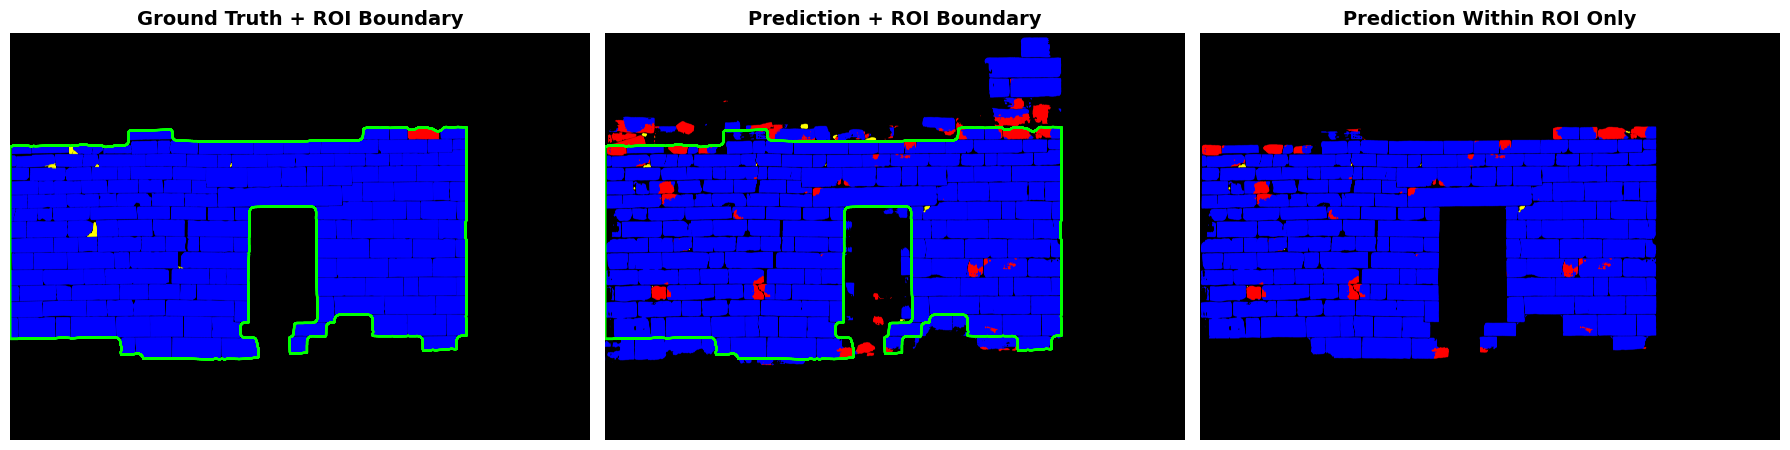

In [124]:
# Final comparison visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

cmap = ListedColormap(CLASS_COLORS)

# Ground truth
axes[0].imshow(gt_mask, cmap=cmap, vmin=0, vmax=3)
axes[0].contour(roi_mask.astype(float) - ndimage.binary_erosion(roi_mask).astype(float), 
                colors='lime', linewidths=1.5)
axes[0].set_title('Ground Truth + ROI Boundary', fontsize=14, fontweight='bold')
axes[0].axis('off')

# Prediction (full)
axes[1].imshow(pred_mask, cmap=cmap, vmin=0, vmax=3)
axes[1].contour(roi_mask.astype(float) - ndimage.binary_erosion(roi_mask).astype(float), 
                colors='lime', linewidths=1.5)
axes[1].set_title('Prediction + ROI Boundary', fontsize=14, fontweight='bold')
axes[1].axis('off')

# Prediction masked to ROI
pred_in_roi = pred_mask.copy()
pred_in_roi[~roi_mask] = 0  # Set outside ROI to background
axes[2].imshow(pred_in_roi, cmap=cmap, vmin=0, vmax=3)
axes[2].set_title('Prediction Within ROI Only', fontsize=14, fontweight='bold')
axes[2].axis('off')

plt.tight_layout()

# Save figure
fig_path = os.path.join(OUTPUT_DIR, 'roi_comparison.png')
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
print(f"✓ Comparison figure saved to: {fig_path}")

plt.show()

---
## Cell 9: IoU Bar Chart

✓ IoU chart saved to: C:/Users/admin/Desktop/OrdnerAmGArtikel2025/AWS_TRAINING/2025-08-10_4classEX/testing/07_ROI_evaluation/Wall4\iou_scores_roi.png


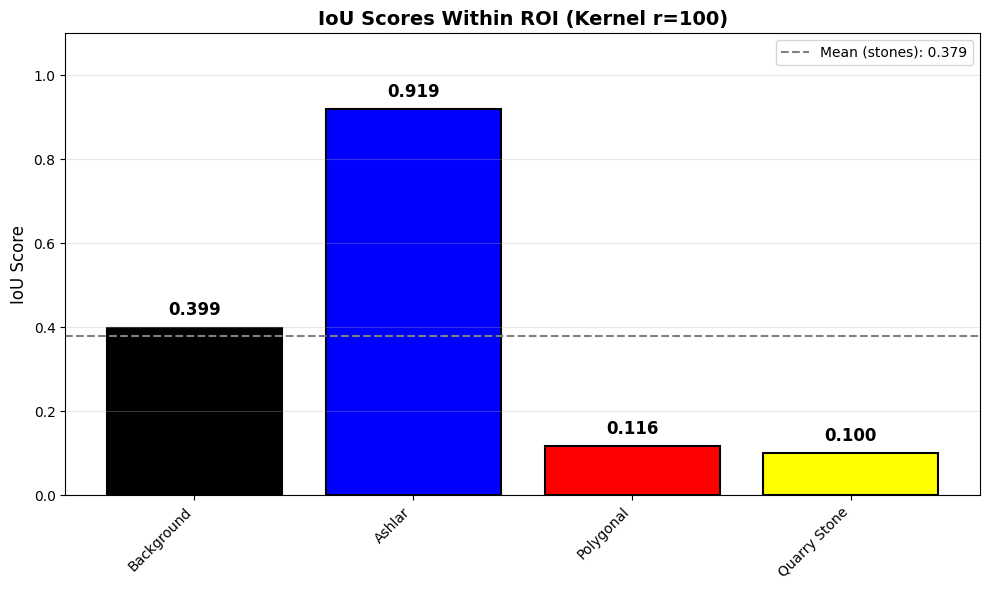

In [125]:
# IoU bar chart
fig, ax = plt.subplots(figsize=(10, 6))

classes = list(iou_scores.keys())
scores = list(iou_scores.values())
colors = [CLASS_COLORS[CLASS_NAMES.index(c)] if c in CLASS_NAMES else '#808080' for c in classes]

bars = ax.bar(classes, scores, color=colors, edgecolor='black', linewidth=1.5)

# Add value labels
for bar, score in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
            f'{score:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=12)

ax.set_ylabel('IoU Score', fontsize=12)
ax.set_title(f'IoU Scores Within ROI (Kernel r={KERNEL_RADIUS})', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1.1)
ax.axhline(y=mean_iou_stones, color='gray', linestyle='--', label=f'Mean (stones): {mean_iou_stones:.3f}')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Save
chart_path = os.path.join(OUTPUT_DIR, 'iou_scores_roi.png')
plt.savefig(chart_path, dpi=150, bbox_inches='tight')
print(f"✓ IoU chart saved to: {chart_path}")

plt.show()